<a href="https://colab.research.google.com/github/sebastianvettel1212/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 2 — Data and Sampling Distributions (Data dan Distribusi Sampling)

**Buku:** *Practical Statistics for Data Scientists* — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly)

Notebook ini berisi:
1. **Reproduksi kode** seluruh contoh pada Bab 2 (Python: `pandas`, `NumPy`, `SciPy`, `scikit-learn`, `seaborn`, `Matplotlib`),
2. **Ringkasan** tiap subbab (*Key Ideas*), dan
3. **Penjelasan teori** dalam Bahasa Indonesia.

---

## Daftar Isi
0. Persiapan: Library & Dataset
1. Random Sampling dan Sample Bias
2. Selection Bias
3. Sampling Distribution dari sebuah Statistik
4. Bootstrap
5. Confidence Interval (Interval Kepercayaan)
6. Distribusi Normal (Standard Normal & QQ-Plot)
7. Distribusi Berekor Panjang (*Long-Tailed*)
8. Distribusi t Student
9. Distribusi Binomial
10. Distribusi Chi-Square
11. Distribusi F
12. Poisson dan Distribusi Terkait (Poisson, Eksponensial, Weibull)
13. Ringkasan Bab

## 0. Persiapan: Library & Dataset

Dataset berasal dari repositori resmi buku ([gedeck/practical-statistics-for-data-scientists](https://github.com/gedeck/practical-statistics-for-data-scientists)). Fungsi `path_data()` memakai file lokal di folder `data/` jika ada, atau **mengunduh otomatis** dari GitHub. Jadi notebook ini dapat langsung dijalankan (termasuk di Google Colab).

Dataset Bab 2: `loans_income.csv` (pendapatan peminjam) dan `sp500_data.csv.gz` (harga saham S&P 500).

In [1]:
# Jalankan sel ini (hapus tanda #) bila library belum terpasang
!pip install pandas numpy scipy scikit-learn seaborn matplotlib

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.utils import resample

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [3]:
# Lokasi dataset: folder lokal 'data/' atau, bila tidak ada, langsung dari GitHub
DATA_DIR = Path('data')
RAW_URL = ('https://raw.githubusercontent.com/gedeck/'
           'practical-statistics-for-data-scientists/master/data/')

def path_data(nama_file):
    lokal = DATA_DIR / nama_file
    return lokal if lokal.exists() else RAW_URL + nama_file

LOANS_INCOME_CSV = path_data('loans_income.csv')
SP500_DATA_CSV   = path_data('sp500_data.csv.gz')

---
## 1. Random Sampling dan Sample Bias

Ilmu statistik klasik banyak berfokus pada **inferensi**: menarik kesimpulan tentang **populasi** dari **sampel**. Di era *big data* pun, sampel tetap relevan, misalnya karena data yang "bersih" dan representatif mahal didapat.

**Istilah kunci**

| Istilah | Penjelasan |
|---|---|
| **Sampel** | Himpunan bagian dari kumpulan data yang lebih besar |
| **Populasi** | Kumpulan data besar atau kumpulan data yang dibayangkan |
| **N (n)** | Ukuran populasi (sampel) |
| **Random sampling** | Menarik elemen ke dalam sampel secara acak; setiap elemen punya peluang sama untuk terpilih |
| **Stratified sampling** | Membagi populasi menjadi strata, lalu mengambil sampel acak dari tiap strata |
| **Stratum (strata)** | Subkelompok populasi dengan karakteristik sama |
| **Simple random sample** | Sampel hasil pengambilan acak tanpa menstratifikasi populasi |
| **Bias** | Kesalahan sistematis (bukan acak) |
| **Sample bias** | Sampel yang tidak mewakili populasi |

- **Sampling dengan pengembalian (*with replacement*)**: elemen yang sudah terpilih dikembalikan ke populasi sehingga dapat terpilih lagi. **Tanpa pengembalian (*without replacement*)**: elemen yang terpilih tidak dapat terpilih lagi.
- **Kualitas data sering lebih penting daripada kuantitas.** Contoh klasik: survei *Literary Digest* 1936 memprediksi Landon mengalahkan Roosevelt dengan 2,4 juta responden, tetapi sampelnya bias (diambil dari daftar pelanggan majalah, pemilik mobil, dan pemilik telepon, kelompok yang relatif kaya) sehingga prediksinya salah. Gallup memakai sampel jauh lebih kecil (sekitar 2.000 orang) namun lebih representatif dan benar.
- **Self-selection sampling**: contohnya ulasan Yelp, yang cenderung ditulis oleh orang yang sangat puas atau sangat kecewa. Hasilnya bisa bias walau ukurannya besar.
- **Bias vs. kesalahan acak**: kesalahan acak akan mengecil seiring bertambahnya data, sedangkan bias **tidak** hilang meski sampel diperbesar.
- **Ukuran sampel vs. kualitas**: untuk kasus tertentu (mis. *search query* langka), data besar justru berguna karena membantu pada kasus yang jarang muncul. Namun untuk estimasi umum, sampel acak kecil yang representatif seringkali lebih baik daripada data besar yang bias.

### Key Ideas
- Meski *big data*, **random sampling** tetap alat penting.
- Bias terjadi bila pengukuran atau pengamatan salah secara sistematis akibat cara data dikumpulkan.
- Kualitas data sering lebih penting daripada kuantitas data.

In [4]:
# Contoh sederhana random sampling: dengan vs tanpa pengembalian
populasi = pd.Series(range(1, 11))
np.random.seed(1)
print('Tanpa pengembalian :', sorted(populasi.sample(5, replace=False)))
print('Dengan pengembalian:', sorted(populasi.sample(5, replace=True)))

Tanpa pengembalian : [1, 3, 5, 7, 10]
Dengan pengembalian: [3, 5, 7, 8, 10]


---
## 2. Selection Bias

**Selection bias** adalah bias akibat cara observasi dipilih. Ini sering muncul pada *data snooping*: menjelajahi data secara berlebihan sampai menemukan pola yang menarik tetapi sebenarnya hanya kebetulan.

**Istilah kunci**
- **Selection bias**: bias yang timbul dari cara memilih data (sadar maupun tidak).
- **Data snooping**: pencarian pola secara ekstensif di data hingga ada yang tampak "menarik".
- **Vast search effect**: bias atau ketidakbisa-direproduksi-nya hasil akibat pemodelan berulang atau banyak model/variabel yang diuji.

**Sifat dasar *vast search effect*.** Jika kita mengajukan cukup banyak pertanyaan pada data, pasti ada jawaban yang tampak signifikan secara kebetulan. Contoh: 20.000 orang melempar koin 10 kali. Beberapa orang akan mendapat 10 kepala berturut-turut hanya karena kebetulan, tetapi itu bukan "bakat".

**Cara melindungi diri**: (1) hipotesis yang jelas di awal, (2) data *holdout* untuk validasi, dan (3) beberapa set data holdout. Jika model akhir diuji pada data yang belum pernah dipakai untuk memilih model, tipuan kebetulan akan terdeteksi.

### Regression to the Mean (Regresi ke Rata-rata)
Fenomena pada pengamatan berurutan: nilai ekstrem cenderung diikuti nilai yang lebih mendekati rata-rata. Contohnya pemain rookie terbaik tahun ini umumnya tampil kurang istimewa tahun depan. Kesalahannya muncul bila kita memberi penjelasan "kausal" pada gejala yang sebenarnya hanya kombinasi *skill* dan keberuntungan.

### Key Ideas
- Menentukan hipotesis lalu mengumpulkan data secara acak mencegah bias.
- Semua pola lain yang ditemukan di data bisa saja kebetulan.
- Waspadai *vast search effect* dan gunakan *holdout*.

In [5]:
# Ilustrasi regression to the mean (tambahan, bukan dari buku):
# kinerja = kemampuan (tetap) + keberuntungan (acak). Pilih 'top 10%' di tahun 1, lihat tahun 2.
rng = np.random.default_rng(42)
kemampuan = rng.normal(0, 1, 10_000)
tahun1 = kemampuan + rng.normal(0, 1, 10_000)
tahun2 = kemampuan + rng.normal(0, 1, 10_000)
top = tahun1 >= np.quantile(tahun1, 0.9)
print(f'Rata-rata tahun 1 (top 10%): {tahun1[top].mean():.3f}')
print(f'Rata-rata tahun 2 (kelompok yang sama): {tahun2[top].mean():.3f}  -> turun mendekati rata-rata')

Rata-rata tahun 1 (top 10%): 2.514
Rata-rata tahun 2 (kelompok yang sama): 1.261  -> turun mendekati rata-rata


---
## 3. Sampling Distribution dari sebuah Statistik

**Sampling distribution** adalah distribusi sebuah *statistik sampel* (mis. rata-rata) yang dihitung dari **banyak sampel** yang diambil dari populasi yang sama.

**Istilah kunci**
- **Sample statistic**: metrik yang dihitung dari sampel.
- **Data distribution**: distribusi nilai-nilai individual dalam dataset.
- **Sampling distribution**: distribusi statistik sampel dari banyak sampel.
- **Central limit theorem (CLT)**: kecenderungan sampling distribution mendekati bentuk normal seiring bertambahnya ukuran sampel.
- **Standard error**: simpangan baku sampling distribution suatu statistik.

Pada praktiknya kita hanya punya **satu** sampel, sehingga sampling distribution dipakai sebagai konsep untuk memahami **variabilitas** estimasi kita.

### Central Limit Theorem
Distribusi data mentah bisa sangat tidak normal (mis. pendapatan yang miring ke kanan), tetapi **distribusi rata-rata sampel** akan mendekati normal ketika ukuran sampel membesar. CLT menjadi dasar banyak uji dan interval kepercayaan klasik. Meski demikian, CLT jarang dibutuhkan pada data science modern karena kita bisa memakai *bootstrap* untuk memperoleh sampling distribution secara empiris.

### Standard Error
Standard error (SE) mengukur variabilitas sampling distribution:

$$SE = \frac{s}{\sqrt{n}}$$

dengan $s$ simpangan baku sampel dan $n$ ukuran sampel. Hubungan $\sqrt{n}$ berarti **untuk menggandakan presisi (SE separuh), butuh sampel 4 kali lebih besar**. *Jangan tertukar:* simpangan baku mengukur sebaran data individual, standard error mengukur sebaran statistik (estimasi).

### Key Ideas
- Distribusi sampling sebuah statistik menunjukkan variasinya antar-sampel.
- CLT: rata-rata dari sampel besar akan terdistribusi normal.
- Standard error = simpangan baku / $\sqrt{n}$.

**Reproduksi Gambar 2-1 / 2-2** — kurva distribusi normal (kiri) dan histogram sampelnya (kanan), lalu histogram data vs. rata-rata 5 dan 20 pengamatan.

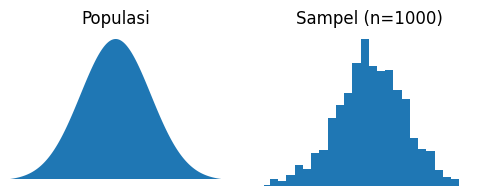

In [6]:
# Gambar 2-1: distribusi populasi (kurva) dan sampel (histogram)
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(6, 2))
axes[0].fill(x, stats.norm.pdf(x))
axes[0].set_title('Populasi')
axes[1].hist(xsample, bins=30)
axes[1].set_title('Sampel (n=1000)')
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_axis_off()
plt.show()

In [7]:
# Gambar 2-2: histogram data, rata-rata 5 data, dan rata-rata 20 data (pendapatan peminjam)
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')

sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})
sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})
sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

         income  type
40292   63000.0  Data
38959   92000.0  Data
17361  134000.0  Data
33996   52000.0  Data
26491   43000.0  Data


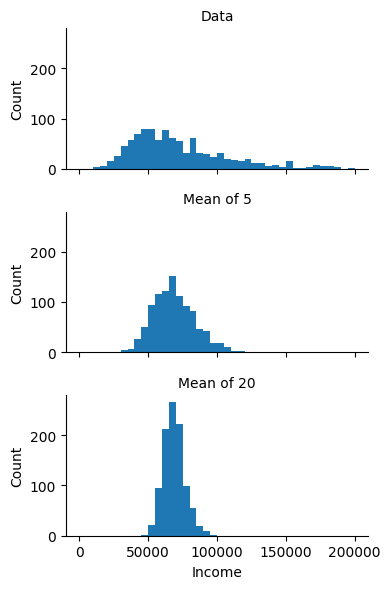

In [8]:
g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

**Interpretasi:** histogram data individual sangat miring ke kanan. Rata-rata 5 data sudah lebih simetris, dan rata-rata 20 data hampir berbentuk lonceng (normal) serta **jauh lebih sempit**. Inilah CLT beserta efek mengecilnya standard error saat $n$ bertambah.

In [9]:
# Tambahan: verifikasi standard error = s / sqrt(n) secara numerik
for ukuran in [5, 20, 80]:
    rata2 = [loans_income.sample(ukuran).mean() for _ in range(2000)]
    se_teori = loans_income.std() / np.sqrt(ukuran)
    print(f'n={ukuran:>3} | SE empiris = {np.std(rata2):>9.1f} | SE teori (s/sqrt(n)) = {se_teori:>9.1f}')

n=  5 | SE empiris =   14460.2 | SE teori (s/sqrt(n)) =   14700.8
n= 20 | SE empiris =    7379.7 | SE teori (s/sqrt(n)) =    7350.4
n= 80 | SE empiris =    3690.2 | SE teori (s/sqrt(n)) =    3675.2


---
## 4. Bootstrap

**Bootstrap** adalah cara praktis untuk memperkirakan sampling distribution suatu statistik: **ambil ulang sampel (dengan pengembalian) dari sampel itu sendiri**, ulangi ribuan kali, hitung statistiknya setiap kali.

**Istilah kunci**
- **Bootstrap sample**: sampel yang diambil dengan pengembalian dari sampel asli.
- **Resampling**: proses mengambil sampel berulang dari data yang diamati (mencakup bootstrap dan permutasi).

**Algoritma bootstrap** (untuk sampel berukuran $n$):
1. Ambil satu nilai acak dari sampel, catat, lalu **kembalikan**.
2. Ulangi $n$ kali.
3. Hitung statistik dari sampel ulang tersebut.
4. Ulangi langkah 1 sampai 3 sebanyak $R$ kali.
5. Gunakan $R$ hasil untuk: (a) menghitung simpangan baku (**standard error**), (b) membuat histogram/boxplot, dan (c) mencari **confidence interval**.

Bootstrap tidak mengompensasi sampel yang kecil dan tidak menciptakan data baru. Ia hanya memberi gambaran bagaimana statistik akan berubah bila sampel diambil dari populasi yang sama. *Resampling* tidak sama dengan *bootstrapping*: resampling juga mencakup tes permutasi (Bab 3).

### Key Ideas
- Bootstrap = ambil sampel dengan pengembalian dari sampel, hitung statistik, ulangi.
- Bisa dipakai untuk statistik apa pun (median, rasio, dll.) tanpa asumsi distribusi.
- Hasilnya dipakai untuk menaksir **bias**, **standard error**, dan **interval kepercayaan**.

In [10]:
# Bootstrap median pendapatan (1000 pengulangan)
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)

print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -74.25149999999849
std. error: 223.90934413762778


**Interpretasi:** *bias* kecil berarti rata-rata median bootstrap sangat dekat dengan median asli, dan *std. error* menunjukkan seberapa besar median akan berfluktuasi antar-sampel.

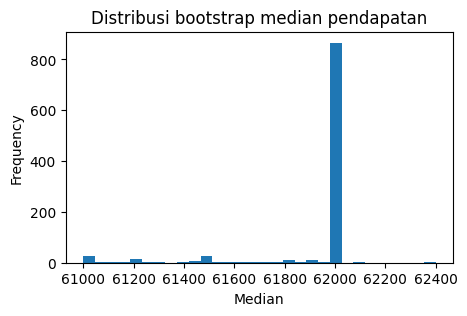

In [11]:
# Tambahan: histogram distribusi bootstrap median
results.plot.hist(bins=30, figsize=(5, 3), title='Distribusi bootstrap median pendapatan')
plt.xlabel('Median'); plt.show()

---
## 5. Confidence Interval (Interval Kepercayaan)

Estimasi tunggal (*point estimate*) tidak memberi gambaran ketidakpastian. **Confidence interval** memberikan **rentang** nilai yang dibangun dari sampel.

**Istilah kunci**
- **Confidence level**: persentase interval kepercayaan yang diharapkan memuat statistik sebenarnya, bila prosedur dilakukan berulang.
- **Interval endpoints**: batas atas dan bawah interval.

**Interpretasi.** Interval 90% berarti: dari banyak sampel, sekitar 90% interval yang dibangun dengan cara ini akan memuat nilai populasi sebenarnya. Pengertian praktis yang sering dipakai: *"rentang yang meliputi bagian tengah 90% distribusi sampling"*. *Bukan* "probabilitas 90% parameter berada di dalam interval ini" (pandangan Bayesian), walau banyak praktisi memakai penafsiran informal itu.

**Bootstrap CI untuk $\bar{x}$** (sampel berukuran $n$), langkah:
1. Ambil bootstrap sample sebanyak $R$ kali.
2. Hitung rata-rata tiap sampel.
3. Untuk interval $x\%$, buang $(100-x)/2$ persen di tiap ujung distribusi hasil. Titik potongnya adalah batas interval.

**Hubungan dengan lebar interval**: semakin tinggi *confidence level*, semakin lebar interval; semakin kecil sampel, semakin lebar interval.

### Key Ideas
- CI menunjukkan rentang ketidakpastian estimasi.
- Bootstrap adalah cara umum untuk menghitung CI.
- Level kepercayaan lebih tinggi, interval lebih lebar. Sampel lebih besar, interval lebih sempit.

In [12]:
# Rata-rata populasi vs rata-rata sampel acak berukuran 20
print('Rata-rata populasi:', loans_income.mean())

np.random.seed(seed=3)
sample20 = resample(loans_income, n_samples=20, replace=False)
print('Rata-rata sampel 20:', sample20.mean())

# Bootstrap rata-rata dari sampel 20 (500 pengulangan)
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
print('Interval kepercayaan 90%:', confidence_interval)

Rata-rata populasi: 68760.51844
Rata-rata sampel 20: 55734.1
Interval kepercayaan 90%: [43212.45, 70233.43999999999]


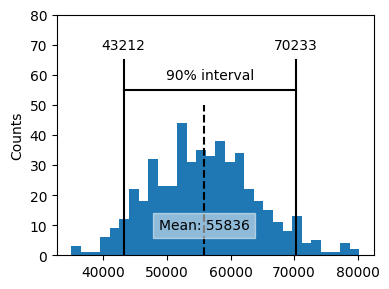

In [13]:
# Gambar 2-9: confidence interval 90% hasil bootstrap
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')
plt.tight_layout()
plt.show()

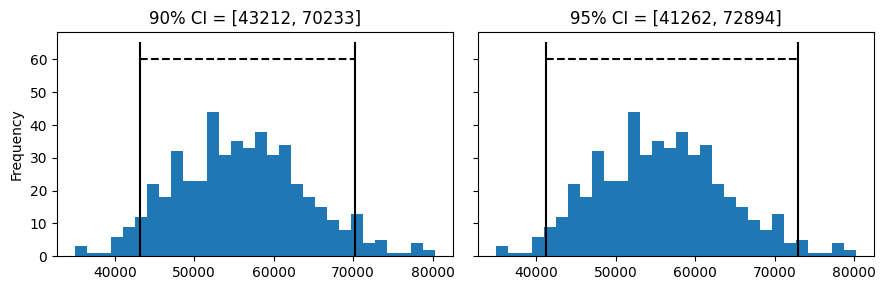

In [14]:
# Gambar 2-10: perbandingan interval 90% vs 95% (sampel yang sama)
np.random.seed(seed=3)
sample20 = resample(loans_income, n_samples=20, replace=False)
results = pd.Series([resample(sample20).mean() for _ in range(500)])

fig, axes = plt.subplots(ncols=2, figsize=(9, 3), sharey=True)
for ax, (lo, hi, lbl) in zip(axes, [(0.05, 0.95, '90%'), (0.025, 0.975, '95%')]):
    ci = list(results.quantile([lo, hi]))
    results.plot.hist(bins=30, ax=ax)
    ax.plot(ci, [60, 60], color='black', linestyle='--')
    for x in ci:
        ax.plot([x, x], [0, 65], color='black')
    ax.set_title(f'{lbl} CI = [{ci[0]:.0f}, {ci[1]:.0f}]')
plt.tight_layout(); plt.show()

**Interpretasi:** interval 95% **lebih lebar** daripada interval 90%. Untuk keyakinan lebih tinggi, kita harus menerima rentang yang lebih longgar.

---
## 6. Distribusi Normal

Distribusi normal (kurva lonceng/Gauss) simetris: sekitar **68%** data berada dalam $\pm 1$ simpangan baku dari rata-rata, **95%** dalam $\pm 2$, dan **99,7%** dalam $\pm 3$.

**Istilah kunci**
- **Error**: selisih antara titik data dan nilai prediksi/rata-rata.
- **Standardize**: kurangi rata-rata lalu bagi dengan simpangan baku.
- **z-score**: hasil standardisasi suatu observasi individu.
- **Standard normal**: distribusi normal dengan rata-rata 0 dan simpangan baku 1.
- **QQ-Plot**: grafik untuk melihat seberapa dekat distribusi sampel dengan distribusi tertentu (mis. normal).

$$z = \frac{x - \bar{x}}{s}$$

Pada **standard normal**, sumbu-$x$ dalam satuan z-score = jumlah simpangan baku dari rata-rata. Menstandardisasi data **tidak membuatnya normal**; hanya menskalakannya.

### QQ-Plot
QQ-plot mengurutkan nilai z-score dari sampel lalu memplotnya terhadap kuantil teoretis distribusi normal. Jika titik-titik **berada di sekitar garis diagonal**, data mendekati normal. Ini lebih informatif daripada sekadar histogram.

### Key Ideas
- Distribusi normal secara historis penting karena CLT, tetapi **data mentah umumnya tidak normal**.
- Pada data normal, 68/95/99,7% data berada dalam 1/2/3 simpangan baku.
- QQ-plot adalah cara visual untuk menguji kenormalan data.

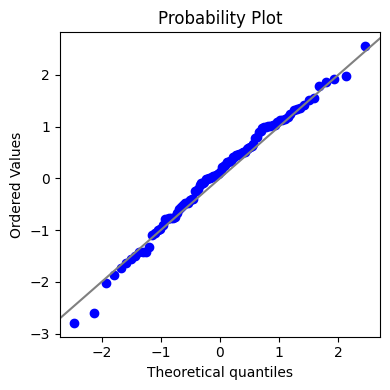

In [15]:
# Gambar 2-11: QQ-plot sampel normal standar (n=100)
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax, fit=False)   # fit=False: tidak mencocokkan garis regresi
ax.axline((0, 0), (1, 1), color='grey')            # diagonal = distribusi normal standar
plt.tight_layout()
plt.show()

In [16]:
# Tambahan: aturan 68-95-99.7 pada distribusi normal standar
for k in [1, 2, 3]:
    print(f'P(-{k} < Z < {k}) = {stats.norm.cdf(k) - stats.norm.cdf(-k):.4f}')

P(-1 < Z < 1) = 0.6827
P(-2 < Z < 2) = 0.9545
P(-3 < Z < 3) = 0.9973


---
## 7. Distribusi Berekor Panjang (*Long-Tailed*)

Walaupun distribusi normal penting, data nyata sering **tidak** normal. Banyak data memiliki **ekor panjang (tebal)**, yaitu peluang nilai ekstrem jauh lebih besar daripada yang diperkirakan distribusi normal.

**Istilah kunci**
- **Tail**: ujung panjang dan sempit suatu distribusi, tempat nilai ekstrem berada.
- **Skewness**: kemiringan distribusi, yaitu satu ekor lebih panjang dari ekor lainnya.

Contoh di buku: *log-return* harian saham Netflix. Pada QQ-plot, titik-titik di bagian tengah mengikuti diagonal, tetapi **ujung-ujungnya melenceng jauh**: kejadian ekstrem (mis. penurunan besar) jauh lebih sering daripada prediksi distribusi normal. Ini penting di keuangan, karena menganggap data normal akan **meremehkan risiko kejadian langka** (*black swan*).

### Key Ideas
- Sebagian besar data tidak berdistribusi normal.
- Menganggap data normal dapat meremehkan kejadian ekstrem.
- Distribusi berekor panjang dikenali pada QQ-plot lewat titik yang menyimpang di ujung.

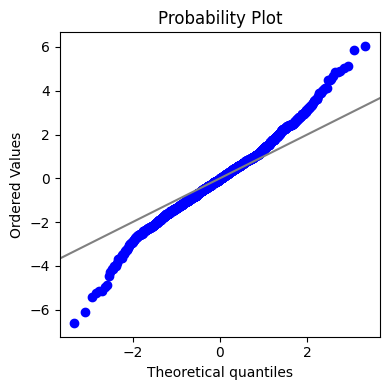

In [17]:
# Gambar 2-12: QQ-plot log-return harian saham Netflix
sp500_px = pd.read_csv(SP500_DATA_CSV)
nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))   # log-return harian

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax, fit=False)
ax.axline((0, 0), (1, 1), color='grey')
plt.tight_layout()
plt.show()

**Interpretasi:** titik-titik di ujung kiri dan kanan keluar jauh dari diagonal, tanda **ekor tebal** pada return Netflix.

In [18]:
# Tambahan: ukuran kuantitatif ekor tebal (skewness & kurtosis berlebih; normal = 0 untuk keduanya)
print('Skewness        :', round(stats.skew(nflx), 3))
print('Excess kurtosis :', round(stats.kurtosis(nflx), 3), '(>0 berarti ekor lebih tebal dari normal)')

Skewness        : 0.074
Excess kurtosis : 1.225 (>0 berarti ekor lebih tebal dari normal)


---
## 8. Distribusi t Student

**Distribusi t** mirip normal tetapi **ekornya sedikit lebih tebal**. Dipakai untuk menggambarkan sampling distribution rata-rata dari **sampel kecil** (dikembangkan oleh W. S. Gosset, alias "Student", saat bekerja di pabrik bir Guinness).

Bentuknya bergantung pada **derajat kebebasan** (*degrees of freedom*, $df = n-1$). Semakin besar $n$, distribusi t makin mirip normal.

Penggunaan utama: **CI** dan **uji hipotesis** untuk rata-rata sampel kecil, serta koefisien regresi. Pada praktiknya, perangkat lunak yang mengurus ini, sehingga yang penting adalah memahami konsepnya.

### Key Ideas
- Distribusi t dipakai untuk sampling distribution rata-rata, terutama pada sampel kecil.
- Ekornya lebih tebal daripada normal; mendekati normal saat $df$ membesar.
- Banyak prosedur statistik klasik (t-test, CI, regresi) berbasis distribusi t.

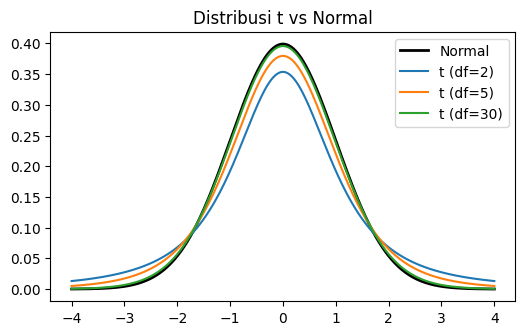

df=  4: t* = 2.776
df=  9: t* = 2.262
df= 29: t* = 2.045
df=999: t* = 1.962
Normal  : z* = 1.96


In [19]:
# Tambahan (tidak ada kode di buku): membandingkan distribusi t dengan normal
x = np.linspace(-4, 4, 400)
plt.figure(figsize=(6, 3.5))
plt.plot(x, stats.norm.pdf(x), 'k', lw=2, label='Normal')
for df in [2, 5, 30]:
    plt.plot(x, stats.t.pdf(x, df), label=f't (df={df})')
plt.legend(); plt.title('Distribusi t vs Normal'); plt.show()

# Nilai kritis 95% (dua sisi): makin besar df, makin mendekati 1.96
for df in [4, 9, 29, 999]:
    print(f'df={df:>3}: t* = {stats.t.ppf(0.975, df):.3f}')
print('Normal  : z* =', round(stats.norm.ppf(0.975), 3))

---
## 9. Distribusi Binomial

**Distribusi binomial** menggambarkan jumlah "sukses" dalam $n$ percobaan **biner** independen (ya/tidak, 1/0).

**Istilah kunci**
- **Trial**: satu percobaan dengan hasil diskrit (mis. lempar koin).
- **Success**: hasil yang menjadi perhatian pada suatu percobaan.
- **Binomial**: memiliki dua hasil (ya/tidak, 0/1, sukses/gagal).
- **Binomial trial**: percobaan dengan dua hasil.
- **Binomial distribution**: distribusi jumlah sukses pada $n$ percobaan.

Parameter: $n$ (jumlah percobaan) dan $p$ (probabilitas sukses). Fungsi massa peluang:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Rata-rata $= np$, varians $= np(1-p)$. Bila $np$ dan $n(1-p)$ cukup besar (sekitar $\geq 10$), distribusi binomial **mendekati normal**.

Contoh buku: peluang mendapat **tepat 2 klik** dari 5 tayangan iklan jika peluang klik 10%, dan peluang **paling banyak 2 klik**.

### Key Ideas
- Binomial = banyaknya sukses pada $n$ percobaan biner independen dengan peluang sukses $p$.
- `stats.binom.pmf` untuk peluang tepat $k$, `stats.binom.cdf` untuk peluang $\leq k$.
- Untuk $n$ besar, binomial dapat didekati dengan normal.

In [20]:
# P(tepat 2 sukses) dan P(paling banyak 2 sukses), n=5, p=0.1
print(stats.binom.pmf(2, n=5, p=0.1))
print(stats.binom.cdf(2, n=5, p=0.1))

0.07289999999999992
0.99144


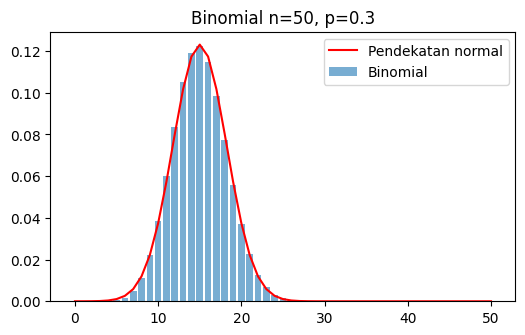

In [21]:
# Tambahan: bentuk distribusi binomial dan pendekatan normalnya (n=50, p=0.3)
n_, p_ = 50, 0.3
k = np.arange(0, 51)
plt.figure(figsize=(6, 3.5))
plt.bar(k, stats.binom.pmf(k, n_, p_), alpha=0.6, label='Binomial')
plt.plot(k, stats.norm.pdf(k, n_*p_, np.sqrt(n_*p_*(1-p_))), 'r', label='Pendekatan normal')
plt.legend(); plt.title('Binomial n=50, p=0.3'); plt.show()

---
## 10. Distribusi Chi-Square

Distribusi **chi-square ($\chi^2$)** dipakai untuk mengukur sejauh mana data pengamatan menyimpang dari yang diharapkan pada data **hitungan (frekuensi)**, misalnya dalam **uji chi-square** (dibahas di Bab 3) dan uji independensi pada tabel kontingensi.

Statistik chi-square diukur sebagai jumlah selisih kuadrat antara nilai pengamatan dan nilai harapan, relatif terhadap harapan. Nilai kecil berarti data sesuai dengan harapan (hipotesis nol), nilai besar berarti ada penyimpangan. Distribusi chi-square bergantung pada derajat kebebasan, dan bila nilainya melebihi nilai kritis maka hipotesis nol ditolak.

### Key Ideas
- Chi-square dipakai untuk menguji kecocokan data hitungan dengan distribusi/harapan tertentu.
- Terkait erat dengan uji independensi pada tabel kontingensi (Bab 3).
- Bentuknya miring ke kanan untuk $df$ kecil dan mendekati normal untuk $df$ besar.

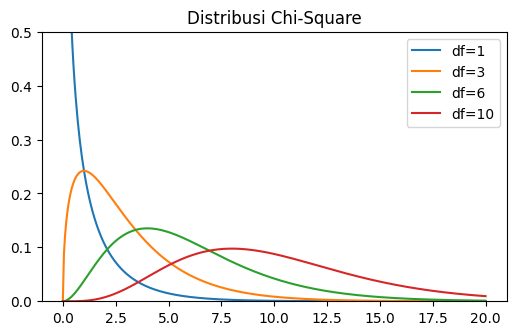

Nilai kritis chi-square 5% (df=3): 7.815


In [22]:
# Tambahan: bentuk distribusi chi-square untuk beberapa derajat kebebasan
x = np.linspace(0, 20, 400)
plt.figure(figsize=(6, 3.5))
for df in [1, 3, 6, 10]:
    plt.plot(x, stats.chi2.pdf(x, df), label=f'df={df}')
plt.ylim(0, 0.5); plt.legend(); plt.title('Distribusi Chi-Square'); plt.show()
print('Nilai kritis chi-square 5% (df=3):', round(stats.chi2.ppf(0.95, 3), 3))

---
## 11. Distribusi F

**Distribusi F** dipakai pada pengujian yang membandingkan **variabilitas antar-kelompok** dengan **variabilitas dalam kelompok** (ANOVA, Bab 3) dan pada pengujian signifikansi keseluruhan model regresi (Bab 4). **Statistik F** adalah rasio dua varians:

$$F = \frac{\text{variabilitas antar-kelompok}}{\text{variabilitas dalam kelompok}}$$

Distribusi F memiliki **dua** derajat kebebasan (pembilang dan penyebut). Nilai F yang besar menunjukkan bahwa perbedaan antar-kelompok lebih besar daripada yang diharapkan secara kebetulan.

### Key Ideas
- Statistik F membandingkan variabilitas antar-kelompok dengan variabilitas dalam kelompok.
- Dipakai pada ANOVA dan regresi.
- Distribusinya bergantung pada dua derajat kebebasan.

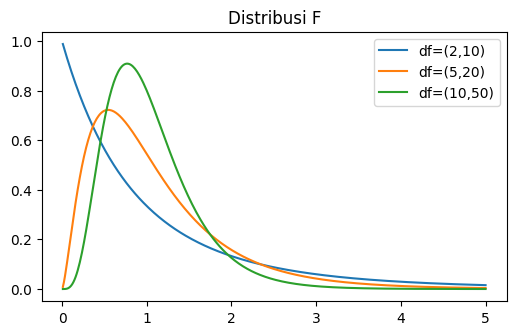

Nilai kritis F 5% (df1=3, df2=20): 3.098


In [23]:
# Tambahan: distribusi F dan nilai kritis
x = np.linspace(0.01, 5, 400)
plt.figure(figsize=(6, 3.5))
for d1, d2 in [(2, 10), (5, 20), (10, 50)]:
    plt.plot(x, stats.f.pdf(x, d1, d2), label=f'df=({d1},{d2})')
plt.legend(); plt.title('Distribusi F'); plt.show()
print('Nilai kritis F 5% (df1=3, df2=20):', round(stats.f.ppf(0.95, 3, 20), 3))

---
## 12. Poisson dan Distribusi Terkait

Banyak proses menghasilkan kejadian secara acak pada laju tertentu (pelanggan tiba, kerusakan mesin, dll.). Distribusi berikut berguna untuk memodelkannya.

### 12.1 Distribusi Poisson
Menggambarkan **jumlah kejadian per satuan waktu/ruang**, dengan parameter $\lambda$ (laju rata-rata per unit). Rata-rata dan varians sama dengan $\lambda$. Contoh: jumlah pelanggan yang datang per menit, atau jumlah cacat per meter kain.

### 12.2 Distribusi Eksponensial
Menggambarkan **selang waktu antara dua kejadian** pada proses Poisson dengan laju $\lambda$. Parameter `scale` $=1/\lambda$.

### 12.3 Mengestimasi Laju Kegagalan
Pada analisis *reliability* (mis. umur mesin), laju kegagalan dapat diestimasi dari data. Jika tidak ada data, ia dapat disimulasikan dengan percobaan atau estimasi berbasis pakar.

### 12.4 Distribusi Weibull
Generalisasi eksponensial yang memungkinkan **laju kejadian berubah seiring waktu**, dengan parameter bentuk $\beta$ dan parameter skala $\eta$. Bila $\beta > 1$, laju kegagalan **naik** seiring waktu (keausan); bila $\beta < 1$, **turun** (kerusakan dini); bila $\beta = 1$, kembali ke eksponensial.

### Key Ideas
- Poisson: jumlah kejadian per unit; Eksponensial: waktu antar kejadian; Weibull: waktu antar kejadian dengan laju yang berubah.
- Parameter $\lambda$ dari Poisson/eksponensial sering diestimasi dari data.
- Weibull bermanfaat untuk analisis umur dan kegagalan.

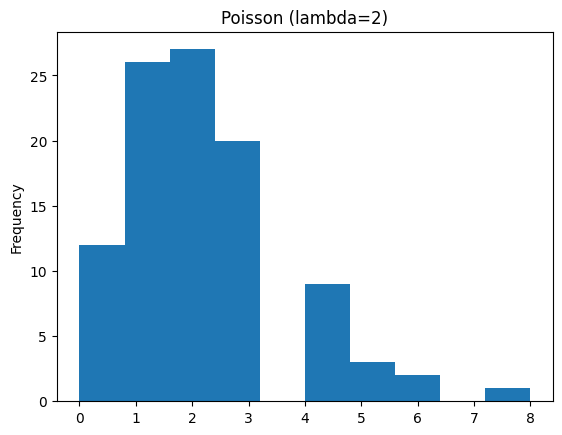

In [24]:
# Distribusi Poisson: lambda = 2, 100 sampel
sample = stats.poisson.rvs(2, size=100)
pd.Series(sample).plot.hist(title='Poisson (lambda=2)')
plt.show()

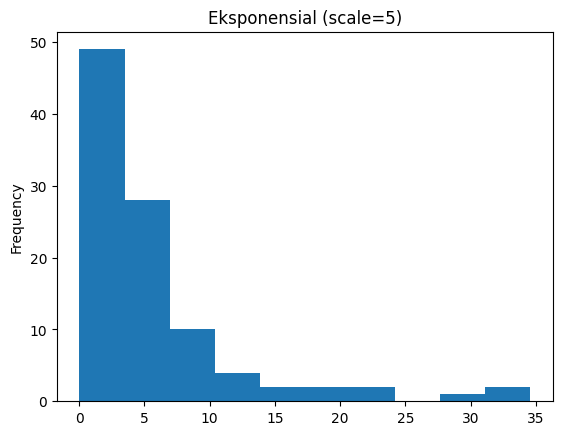

In [25]:
# Distribusi eksponensial: scale = 5 (rata-rata selang antar kejadian = 5), 100 sampel
sample = stats.expon.rvs(scale=5, size=100)
pd.Series(sample).plot.hist(title='Eksponensial (scale=5)')
plt.show()

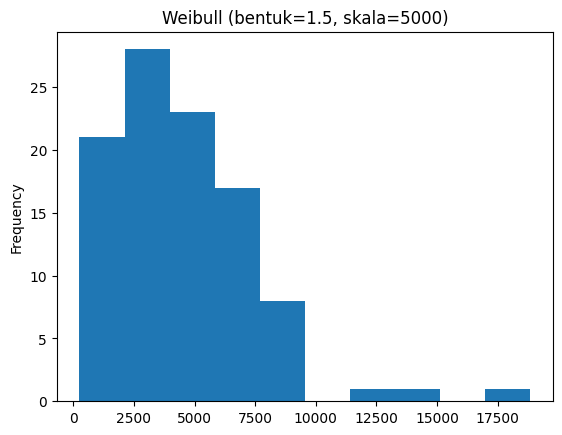

In [26]:
# Distribusi Weibull: bentuk 1.5, skala 5000, 100 sampel
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)
pd.Series(sample).plot.hist(title='Weibull (bentuk=1.5, skala=5000)')
plt.show()

---
## 13. Ringkasan Bab

Bab 2 menjelaskan fondasi **inferensi statistik**: bagaimana kita menarik kesimpulan tentang populasi dari sampel.

| Konsep | Inti |
|---|---|
| **Random sampling & bias** | Sampel acak yang representatif lebih penting daripada sekadar data yang besar; bias tidak hilang walau $n$ besar |
| **Selection bias** | Waspadai *data snooping*, *vast search effect*, dan *regression to the mean*; gunakan data *holdout* |
| **Sampling distribution** | Distribusi statistik sampel; CLT: rata-rata cenderung normal; $SE = s/\sqrt{n}$ |
| **Bootstrap** | Resampling dengan pengembalian untuk menaksir bias, SE, dan CI tanpa asumsi distribusi |
| **Confidence interval** | Rentang ketidakpastian estimasi; level lebih tinggi, interval lebih lebar |
| **Normal & QQ-plot** | z-score & aturan 68-95-99,7; QQ-plot untuk memeriksa kenormalan |
| **Long-tailed** | Data nyata sering berekor tebal; asumsi normal meremehkan risiko ekstrem |
| **t, chi-square, F** | Distribusi untuk uji hipotesis dan CI: rata-rata sampel kecil, data hitungan, rasio varians |
| **Binomial, Poisson, eksponensial, Weibull** | Model untuk data biner/hitungan dan waktu antar kejadian |

Konsep-konsep ini menjadi dasar **Bab 3** (uji hipotesis dan eksperimen) dan **Bab 4** (regresi).